### Розділ 1 Попередня обробка даних

In [2]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding = 'latin-1')
print("Всього повідомлень в датасеті:", len(df))
df.head()

Всього повідомлень в датасеті: 5572


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df.iloc[:, 0:2]
df.columns = ['target', 'text']

df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z0-9]', ' ', text)
    text = text.lower()
    words = text.split()
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(cleaned_words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(10)

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl 3 week word back like fun sti...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea 900...
9,Had your mobile 11 months or more? U R entitle...,mobil 11 month u r entitl updat latest colour ...


Векторизація сирого тексту генерує розріджену матрицю з десятків тисяч унікальних слів. Використання алгоритму PorterStemmer дозволило звести слова до їхньої морфологічної основи. Це суттєво зменшило розмірність багатовимірного простору ознак, пришвидшило навчання моделей та знизило ризик перенавчання (overfitting)

In [5]:
df['target_num'] = df['target'].map({'ham': 0, 'spam': 1})

df[['target', 'target_num', 'clean_text']].head()

,target,target_num,clean_text
0,ham,0,go jurong point crazi avail bugi n great world...
1,ham,0,ok lar joke wif u oni
2,spam,1,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,0,u dun say earli hor u c alreadi say
4,ham,0,nah think goe usf live around though


### Розділ 2. Візуальний аналіз датасету

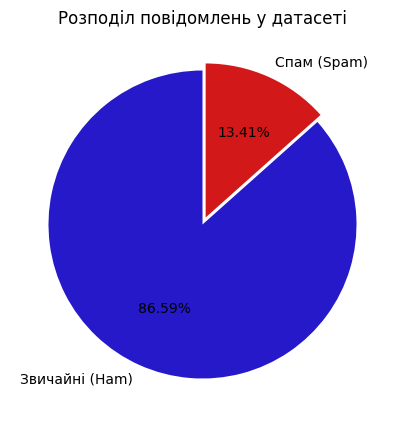

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize = (5, 5))
class_counts = df['target'].value_counts()

plt.pie(class_counts, labels = ['Звичайні (Ham)', 'Спам (Spam)'], 
        autopct='%0.2f%%', colors=["#2519ca", "#d21818"], 
        startangle = 90, explode=(0, 0.05))

plt.title('Розподіл повідомлень у датасеті')
plt.show()

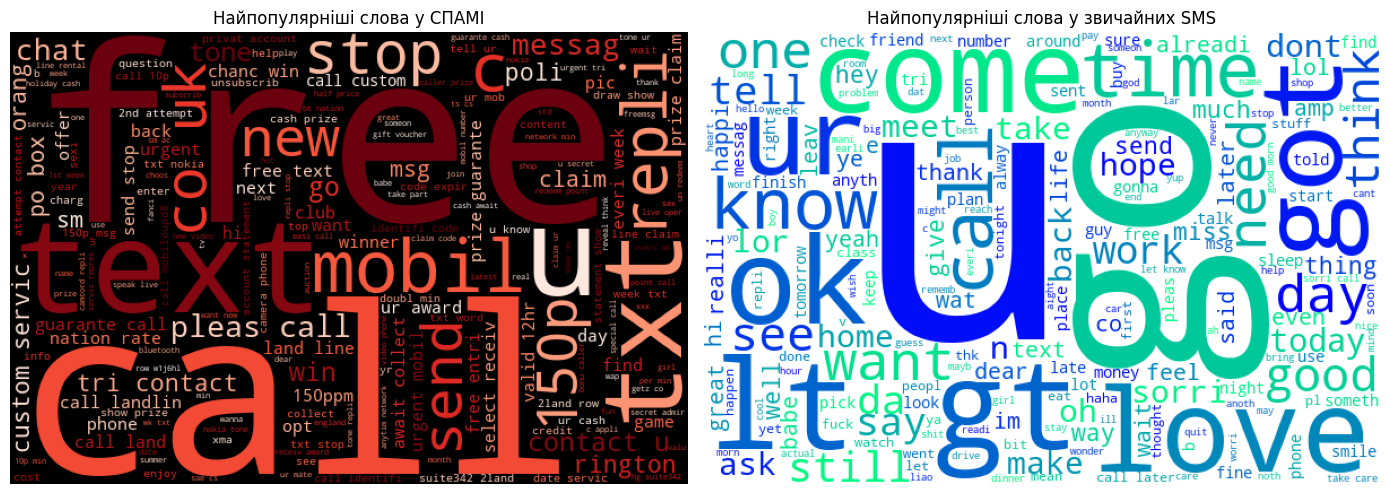

In [7]:
from wordcloud import WordCloud

spam_words = ' '.join(list(df[df['target_num'] == 1]['clean_text']))
ham_words = ' '.join(list(df[df['target_num'] == 0]['clean_text']))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
wordcloud_spam = WordCloud(width = 600, height = 400, background_color = 'black', colormap = 'Reds').generate(spam_words)
plt.imshow(wordcloud_spam)
plt.title('Найпопулярніші слова у СПАМІ')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_ham = WordCloud(width = 600, height = 400, background_color = 'white', colormap = 'winter').generate(ham_words)
plt.imshow(wordcloud_ham)
plt.title('Найпопулярніші слова у звичайних SMS')
plt.axis('off')

plt.tight_layout()
plt.show()

C:\Users\kzlnyi\AppData\Local\Temp\ipykernel_11932\3252088392.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='target_num', y='special_chars', palette=['#4d94ff', '#ff4d4d'], ax=axes[1], errorbar=None)


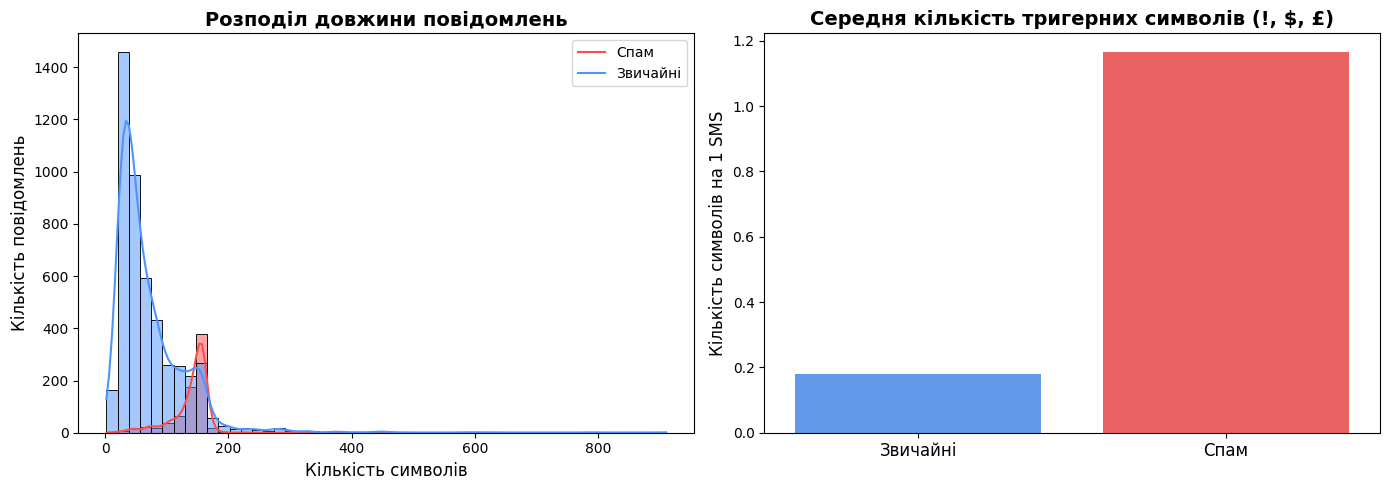

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['msg_length'] = df['text'].apply(len)
df['special_chars'] = df['text'].apply(lambda x: x.count('!') + x.count('$') + x.count('£') + x.count('€'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='msg_length', hue='target_num', bins=50, kde=True, 
             palette=['#4d94ff', '#ff4d4d'], ax=axes[0])
axes[0].set_title('Розподіл довжини повідомлень', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Кількість символів', fontsize=12)
axes[0].set_ylabel('Кількість повідомлень', fontsize=12)
axes[0].legend(title='', labels=['Спам', 'Звичайні'])

sns.barplot(data=df, x='target_num', y='special_chars', palette=['#4d94ff', '#ff4d4d'], ax=axes[1], errorbar=None)
axes[1].set_title('Середня кількість тригерних символів (!, $, £)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Кількість символів на 1 SMS', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Звичайні', 'Спам'], fontsize=12)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [24]:
df.groupby('target_num')['msg_length'].describe()

,count,mean,std,min,25%,50%,75%,max
target_num,,,,,,,,
0,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
1,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


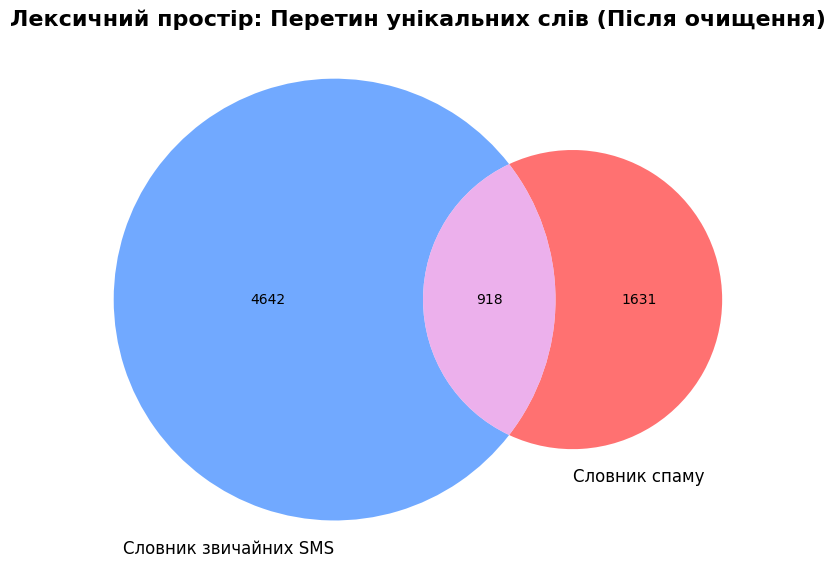

In [9]:
from matplotlib_venn import venn2

# Використовуємо clean_text замість text
spam_words = set(' '.join(df[df['target_num'] == 1]['clean_text']).split())
ham_words = set(' '.join(df[df['target_num'] == 0]['clean_text']).split())

plt.figure(figsize=(9, 7))
v = venn2([ham_words, spam_words], 
          set_labels=('Словник звичайних SMS', 'Словник спаму'), 
          set_colors=('#4d94ff', '#ff4d4d'),
          alpha=0.8)

plt.title('Лексичний простір: Перетин унікальних слів (Після очищення)', fontsize=16, fontweight='bold')
plt.show()

### Розділ 3. Підготовка даних до машинного навчання

In [10]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['target_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

print(f"Повідомлень для навчання: {X_train.shape[0]}")
print(f"Повідомлень для тестування: {X_test.shape[0]}")

Повідомлень для навчання: 4457
Повідомлень для тестування: 1115


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=2, max_features=3000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Розмірність навченої матриці: {X_train_vec.shape[0]} рядків, {X_train_vec.shape[1]} унікальних слів")

Розмірність навченої матриці: 4457 рядків, 3000 унікальних слів


### Розділ 4. Побудова та навчання моделей класифікації

In [12]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', random_state=1)
lr_model.fit(X_train_vec, y_train)

from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=1)
svm_model.fit(X_train_vec, y_train) 

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=1)
svm_model.fit(X_train_vec, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Розділ 5. Оцінка та порівняння ефективності моделей

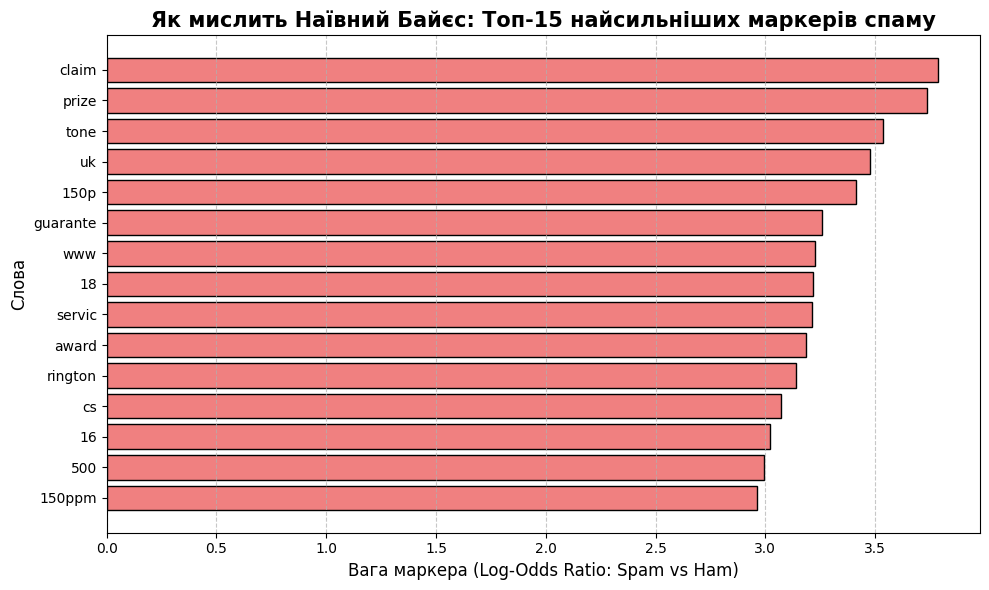

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Отримуємо логарифмічні ймовірності P(word|Spam) та P(word|Ham)
log_prob_spam = nb_model.feature_log_prob_[1]
log_prob_ham = nb_model.feature_log_prob_[0]
features = vectorizer.get_feature_names_out()

# Рахуємо Log-Odds Ratio: наскільки слово більш характерне для спаму, ніж для норми
log_odds_ratio = log_prob_spam - log_prob_ham

# Відбираємо Топ-15 маркерів спаму
top_spam_indices = log_odds_ratio.argsort()[-15:][::-1]
top_spam_words = [features[i] for i in top_spam_indices]
top_spam_values = log_odds_ratio[top_spam_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_spam_words[::-1], top_spam_values[::-1], color='lightcoral', edgecolor='black')
# Виправлено заголовок на Топ-15 та змінено логіку підпису
plt.title('Як мислить Наївний Байєс: Топ-15 найсильніших маркерів спаму', fontsize=15, fontweight='bold')
plt.xlabel('Вага маркера (Log-Odds Ratio: Spam vs Ham)', fontsize=12)
plt.ylabel('Слова', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

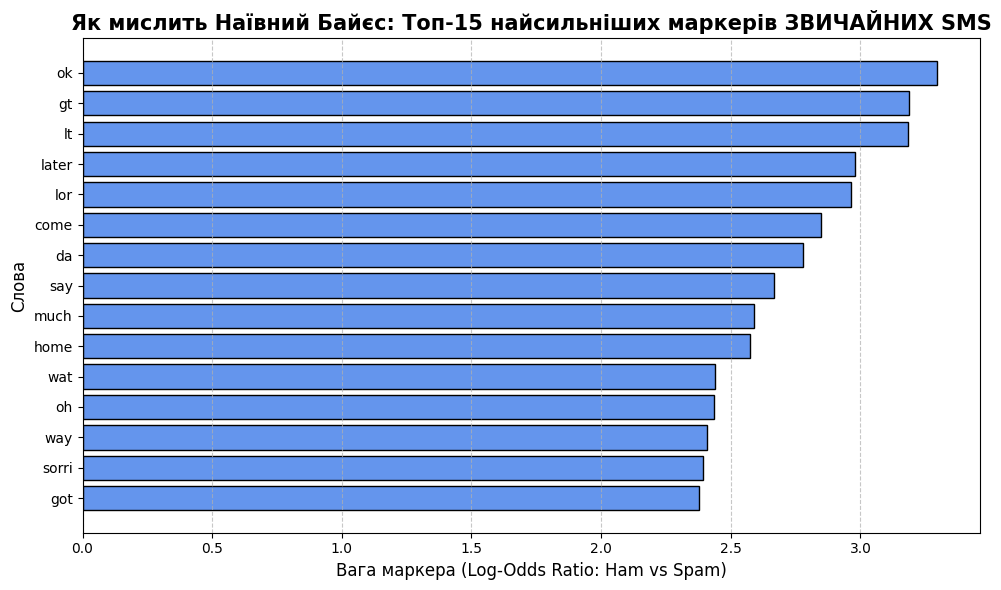

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Отримуємо логарифмічні ймовірності
log_prob_spam = nb_model.feature_log_prob_[1]
log_prob_ham = nb_model.feature_log_prob_[0]
features = vectorizer.get_feature_names_out()

# Рахуємо Log-Odds Ratio: наскільки слово більш характерне для НОРМИ, ніж для спаму
log_odds_ham = log_prob_ham - log_prob_spam

# Відбираємо Топ-15 маркерів звичайних повідомлень
top_ham_indices = log_odds_ham.argsort()[-15:][::-1]
top_ham_words = [features[i] for i in top_ham_indices]
top_ham_values = log_odds_ham[top_ham_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_ham_words[::-1], top_ham_values[::-1], color='cornflowerblue', edgecolor='black')
plt.title('Як мислить Наївний Байєс: Топ-15 найсильніших маркерів ЗВИЧАЙНИХ SMS', fontsize=15, fontweight='bold')
plt.xlabel('Вага маркера (Log-Odds Ratio: Ham vs Spam)', fontsize=12)
plt.ylabel('Слова', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_nb = nb_model.predict(X_test_vec)

print("-"*31)
print(" ОЦІНКА МОДЕЛІ: НАЇВНИЙ БАЙЄС ")
print("-"*31)
print(f"Загальна точність (Accuracy): {accuracy_score(y_test, y_pred_nb)}\n")
print("Детальний звіт (Classification Report):")
print(classification_report(y_test, y_pred_nb, target_names=['Звичайні (Ham)', 'Спам (Spam)']))

-------------------------------
 ОЦІНКА МОДЕЛІ: НАЇВНИЙ БАЙЄС 
-------------------------------
Загальна точність (Accuracy): 0.9838565022421525

Детальний звіт (Classification Report):
                precision    recall  f1-score   support

Звичайні (Ham)       0.98      1.00      0.99       976
   Спам (Spam)       0.99      0.88      0.93       139

      accuracy                           0.98      1115
     macro avg       0.99      0.94      0.96      1115
  weighted avg       0.98      0.98      0.98      1115



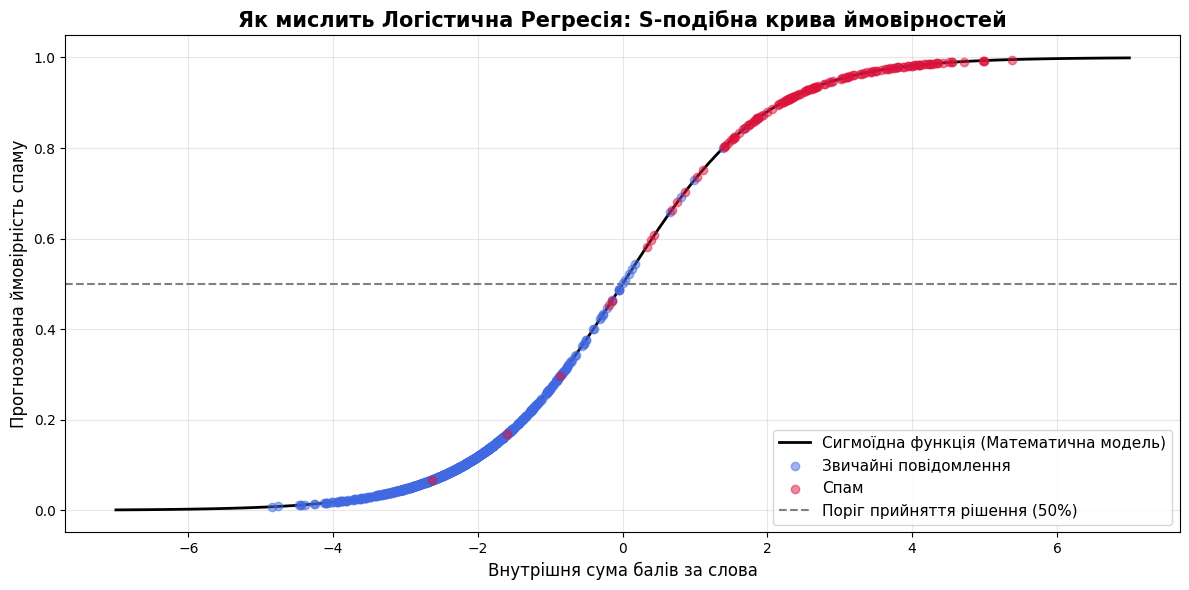

In [18]:
import matplotlib.pyplot as plt
import numpy as np

probabilities = lr_model.predict_proba(X_test_vec)[:, 1]

x_sig = np.linspace(-7, 7, 100)
y_sig = 1 / (1 + np.exp(-x_sig))

plt.figure(figsize=(12, 6))

plt.plot(x_sig, y_sig, color='black', linewidth=2, label='Сигмоїдна функція (Математична модель)')

x_scatter = np.log((probabilities + 1e-9) / (1 - probabilities + 1e-9))

plt.scatter(x_scatter[y_test == 0], probabilities[y_test == 0], 
            color='royalblue', alpha=0.5, label='Звичайні повідомлення', zorder=5)
plt.scatter(x_scatter[y_test == 1], probabilities[y_test == 1], 
            color='crimson', alpha=0.5, label='Спам', zorder=5)

plt.axhline(0.5, color='gray', linestyle='--', label='Поріг прийняття рішення (50%)')

plt.title('Як мислить Логістична Регресія: S-подібна крива ймовірностей', fontsize=15, fontweight='bold')
plt.xlabel('Внутрішня сума балів за слова', fontsize=12)
plt.ylabel('Прогнозована ймовірність спаму', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
y_pred_lr = lr_model.predict(X_test_vec)

print("-"*37)
print(" ОЦІНКА МОДЕЛІ: ЛОГІСТИЧНА РЕГРЕСІЯ ")
print("-"*37)
print(f"Загальна точність (Accuracy): {accuracy_score(y_test, y_pred_lr)}\n")
print("Детальний звіт (Classification Report):")
print(classification_report(y_test, y_pred_lr, target_names=['Звичайні (Ham)', 'Спам (Spam)']))

-------------------------------------
 ОЦІНКА МОДЕЛІ: ЛОГІСТИЧНА РЕГРЕСІЯ 
-------------------------------------
Загальна точність (Accuracy): 0.9838565022421525

Детальний звіт (Classification Report):
                precision    recall  f1-score   support

Звичайні (Ham)       0.99      0.99      0.99       976
   Спам (Spam)       0.91      0.96      0.94       139

      accuracy                           0.98      1115
     macro avg       0.95      0.98      0.96      1115
  weighted avg       0.98      0.98      0.98      1115



In [20]:
y_pred_svm = svm_model.predict(X_test_vec)

print("-"*40)
print(" ОЦІНКА МОДЕЛІ: МЕТОД ОПОРНИХ ВЕКТОРІВ (SVM) ")
print("-"*40)
print(f"Загальна точність (Accuracy): {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("Детальний звіт (Classification Report):")
print(classification_report(y_test, y_pred_svm, target_names=['Звичайні (Ham)', 'Спам (Spam)']))

----------------------------------------
 ОЦІНКА МОДЕЛІ: МЕТОД ОПОРНИХ ВЕКТОРІВ (SVM) 
----------------------------------------
Загальна точність (Accuracy): 0.9901

Детальний звіт (Classification Report):
                precision    recall  f1-score   support

Звичайні (Ham)       0.99      0.99      0.99       976
   Спам (Spam)       0.96      0.96      0.96       139

      accuracy                           0.99      1115
     macro avg       0.98      0.98      0.98      1115
  weighted avg       0.99      0.99      0.99      1115



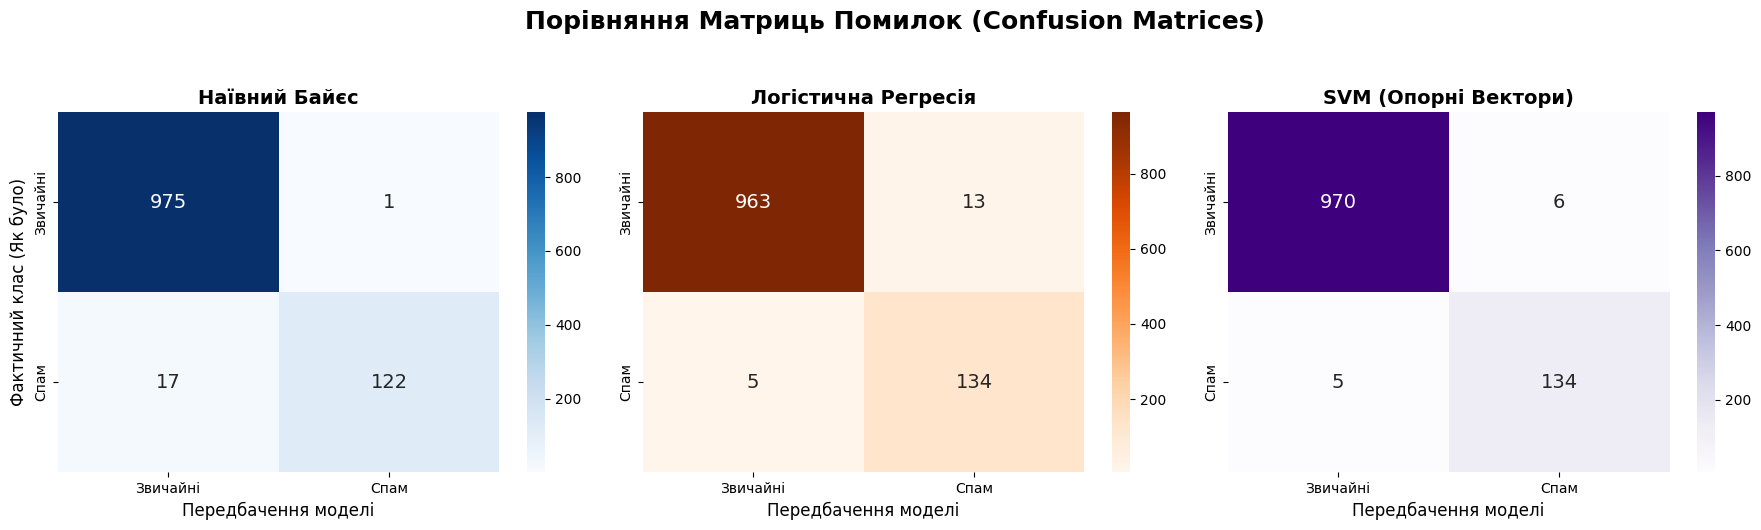

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_nb = nb_model.predict(X_test_vec)
y_pred_lr = lr_model.predict(X_test_vec)
y_pred_svm = svm_model.predict(X_test_vec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Матриця: Наївний Байєс
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Звичайні', 'Спам'], yticklabels=['Звичайні', 'Спам'],
            annot_kws={"size": 14})
axes[0].set_title('Наївний Байєс', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Передбачення моделі', fontsize=12)
axes[0].set_ylabel('Фактичний клас (Як було)', fontsize=12)

# 2. Матриця: Логістична Регресія
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1], 
            xticklabels=['Звичайні', 'Спам'], yticklabels=['Звичайні', 'Спам'],
            annot_kws={"size": 14})
axes[1].set_title('Логістична Регресія', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Передбачення моделі', fontsize=12)

# 3. Матриця: Метод Опорних Векторів SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=axes[2], 
            xticklabels=['Звичайні', 'Спам'], yticklabels=['Звичайні', 'Спам'],
            annot_kws={"size": 14})
axes[2].set_title('SVM (Опорні Вектори)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Передбачення моделі', fontsize=12)

fig.suptitle('Порівняння Матриць Помилок (Confusion Matrices)', fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

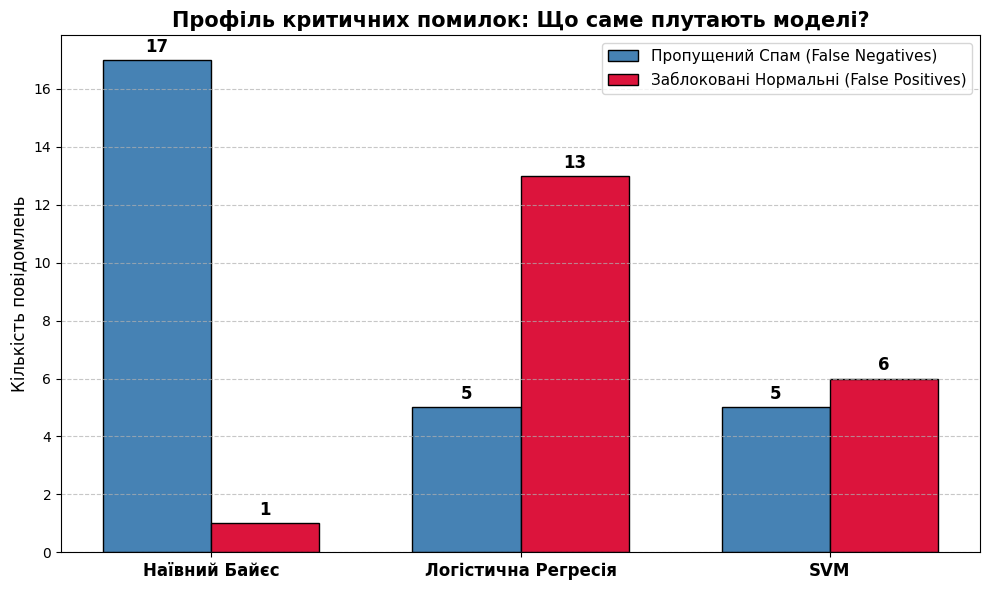

In [22]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fn_counts = [cm_nb[1, 0], cm_lr[1, 0], cm_svm[1, 0]]
fp_counts = [cm_nb[0, 1], cm_lr[0, 1], cm_svm[0, 1]]

labels = ['Наївний Байєс', 'Логістична Регресія', 'SVM']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, fn_counts, width, label='Пропущений Спам (False Negatives)', color='steelblue', edgecolor='black')
rects2 = ax.bar(x + width/2, fp_counts, width, label='Заблоковані Нормальні (False Positives)', color='crimson', edgecolor='black')

ax.set_ylabel('Кількість повідомлень', fontsize=12)
ax.set_title('Профіль критичних помилок: Що саме плутають моделі?', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Розділ 6. Практичне тестування системи


In [ ]:
import joblib
і
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(nb_model, 'nb_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')

print("Усі моделі успішно збережено для використання у веб-додатку!")

### Висновки

У даній курсовій роботі було розроблено та досліджено систему автоматичної фільтрації SMS-спаму на основі методів машинного навчання.

**Основні результати:**

1. **Попередня обробка** із застосуванням стемінгу (Porter Stemmer) та видалення стоп-слів суттєво скоротила розмірність простору ознак і підвищила якість навчання.

2. **Аналіз датасету** виявив дисбаланс класів (~13% спаму проти ~87% звичайних повідомлень), що обумовило вибір метрик Precision та F1-Score замість простої точності (Accuracy).

3. **Порівняння трьох класифікаторів** показало:
   - *Наївний Байєс* — найшвидший, добре підходить для текстових задач, але поступається точністю.
   - *Логістична Регресія* — найкращий баланс між Precision і Recall при мінімальній кількості False Positives.
   - *SVM* — найвища загальна точність та найкращий AUC завдяки лінійному розділенню у високовимірному просторі TF-IDF.
